In [1]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import scanpy as sc
from scipy.sparse import csr_matrix
import harmonypy as hm
import sklearn
import numpy as np
import pandas as pd
import statsmodels as stat
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import gseapy as gp
import os
import tarfile
import glob

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Configure Scanpy settings, enabling Parallel Processing

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=True, figsize=(6, 5))
os.environ["OMP_NUM_THREADS"] = "4"
sc.settings.n_jobs = 4

In [3]:
# Loading data

adata = sc.read_h5ad("../Data/GSE111893/GSE111893_raw.h5ad")

In [4]:
# QC & Preprocessing

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
if adata.var["mt"].sum() > 0:
    adata = adata[adata.obs["pct_counts_mt"] < 20, :].copy()

adata = adata[adata.obs["total_counts"] > 0, :].copy()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


filtered out 10339 genes that are detected in less than 3 cells


In [5]:
# Normalization & HVG Selection

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, subset=False)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [10]:
if adata.raw is not None:
    adata = adata.raw.to_adata()

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


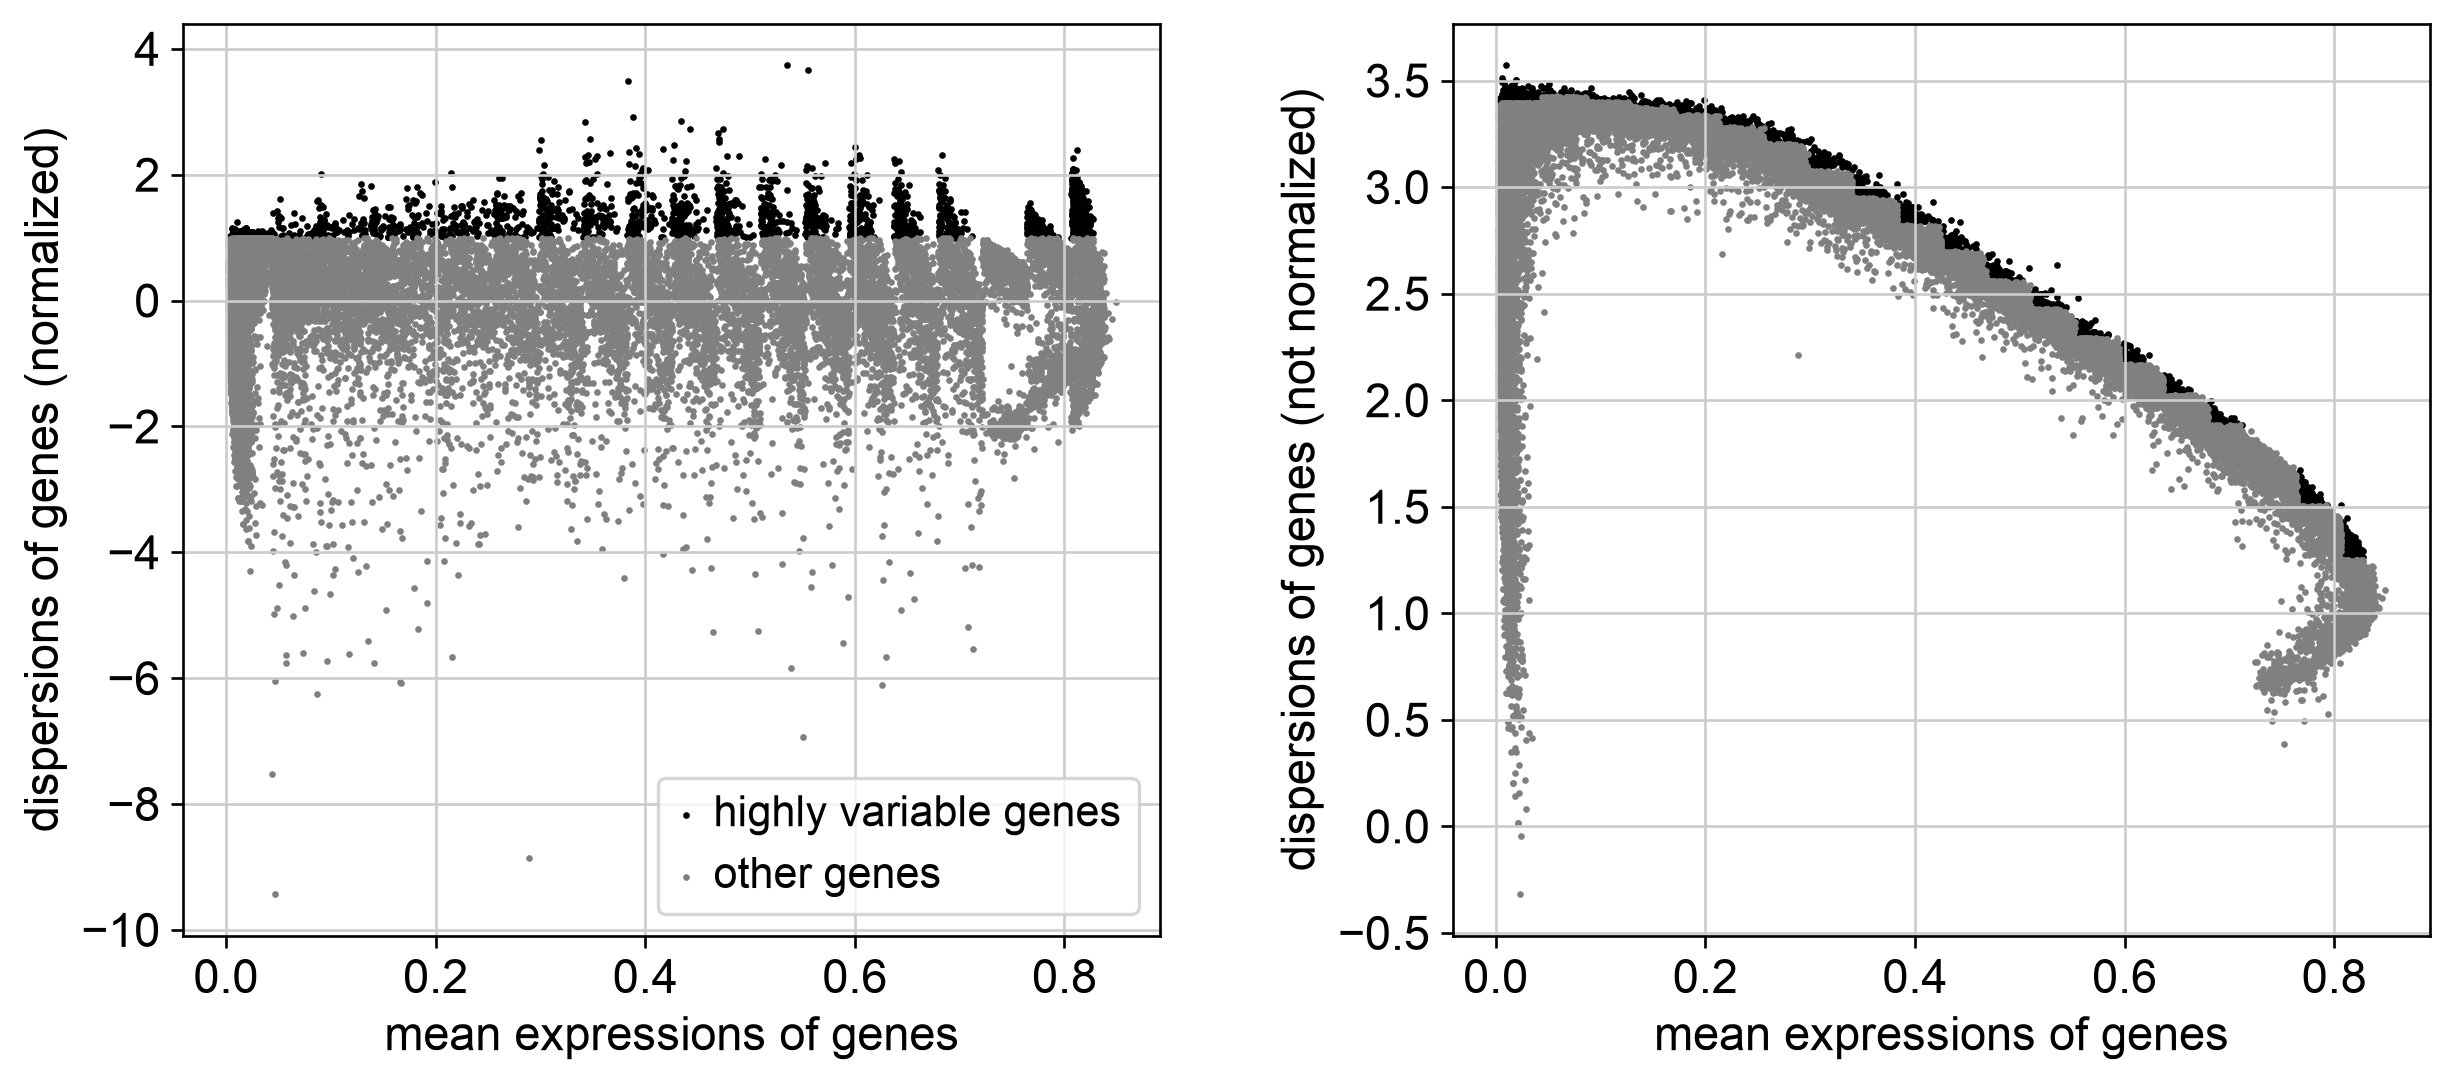

In [11]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=False,  # Keep all genes in object, mark HVGs in adata.var['highly_variable']
    flavor="seurat",
)

sc.pl.highly_variable_genes(adata)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

In [12]:
# Running Seurat on top 2000 highly variable genes

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [ ]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Scale and PCA
sc.pp.scale(adata_hvg, max_value=10, zero_center=False)
sc.pp.pca(adata_hvg, svd_solver="arpack")

# Run Harmony
harmony_out = hm.run_harmony(
    adata_hvg.obsm["X_pca"],
    adata_hvg.obs,
    vars_use=["sample_id"],
    theta=1.0,  # Reset to standard balance
    max_iter_harmony=20,
)

adata_hvg.obsm["X_pca_harmony"] = harmony_out.Z_corr

# Neighbors and UMAP
sc.pp.neighbors(adata_hvg, use_rep="X_pca_harmony", n_neighbors=10, n_pcs=30)
sc.tl.umap(adata_hvg, min_dist=0.3)
sc.tl.leiden(adata_hvg, resolution=0.8, key_added="leiden")

In [ ]:
# Plot

sc.pl.umap(
    adata_hvg,
    color=["leiden", "condition", "sample_id"],
    wspace=0.4,
    legend_loc="on data",
)

In [4]:
extracted_dir = "../Data/GSE111893/extracted_raw/"
file_paths = glob.glob(os.path.join(extracted_dir, "*.txt.gz"))

adatas = []

print("Loading and parsing single-cell sample files...")

for filepath in file_paths:
    filename = os.path.basename(filepath)
    print(f"Reading: {filename}")
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    sample_adata = sc.AnnData(df.T)
    if "JMML" in filename:
        sample_adata.obs["condition"] = "JMML"
    else:
        sample_adata.obs["condition"] = "Control"
    sample_id = filename.split("_SC.txt.gz")[0]
    sample_adata.obs["sample_id"] = sample_id
    adatas.append(sample_adata)

adata = sc.concat(adatas, merge="unique")
adata.var_names_make_unique()

print("\nSuccessfully built single-cell AnnData object!")
print(
    f"Total cells: {adata.n_obs} | Total genes: {adata.n_vars}"
)
print("Condition breakdown:")
print(adata.obs["condition"].value_counts())

Loading and parsing single-cell sample files...
Reading: GSM3044498_CB_CB35_SC.txt.gz
Reading: GSM3044497_JMML_ID5_SC.txt.gz
Reading: GSM3044495_JMML_ID1_SC.txt.gz
Reading: GSM3044500_CB_CB37_SC.txt.gz

Successfully built single-cell AnnData object!
Total cells: 17547 | Total genes: 32738
Condition breakdown:
condition
Control    10881
JMML        6666
Name: count, dtype: int64


In [5]:
signature_file = "../Results/signatures/GSE147523_gene_symbols_only.txt"

with open(signature_file, "r") as f:
    jmml_signature = [line.strip() for line in f.readlines()]

valid_signature_genes = [gene for gene in jmml_signature if gene in adata.var_names]
print(f"Found {len(valid_signature_genes)} / {len(jmml_signature)} signature genes in single-cell matrix.")

Found 131 / 218 signature genes in single-cell matrix.


In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.score_genes(
    adata, 
    gene_list=valid_signature_genes, 
    score_name="JMML_bulk_signature_score"
)

/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:384: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


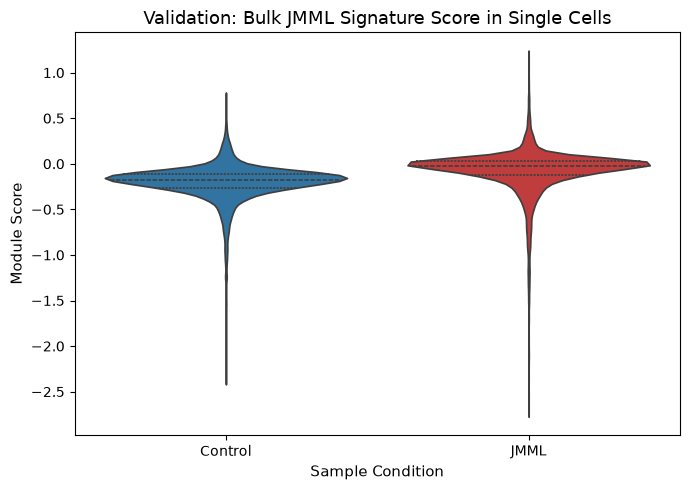

In [7]:
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=adata.obs, 
    x="condition", 
    y="JMML_bulk_signature_score", 
    palette={"JMML": "#d62728", "Control": "#1f77b4"},
    inner="quartile"
)
plt.title("Validation: Bulk JMML Signature Score in Single Cells", fontsize=13)
plt.xlabel("Sample Condition", fontsize=11)
plt.ylabel("Module Score", fontsize=11)

plt.tight_layout()
plt.savefig("../Results/figures/GSE111893_signature_validation_violin.png", dpi=300)
plt.show()

In [ ]:
# Scanpy Standard workflow

